First we need to install the depenencies
In python the packages are installed using pip

pip install matplotlib numpy pandas si_prefix pygmid prettytable

pip list


Then we import the packages

In [1]:
from pygmid import Lookup as look_up
import numpy as np
from prettytable import PrettyTable
import matplotlib.pyplot as plt
from si_prefix import si_format as num2eng
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Arial']

In [2]:
#import the lookup tables
nch_path = 'C:/Users/atorralba/Documents/GitHub/Analog-ICDesign-OpenTools/gmID-Design/PDKs/gf180mcuD/nfet_03v3.mat'
pch_path = 'C:/Users/atorralba/Documents/GitHub/Analog-ICDesign-OpenTools/gmID-Design/PDKs/gf180mcuD/pfet_03v3.mat'

nch = look_up(nch_path)
pch = look_up(pch_path)

The gmID funciton can be used in multiple ways
1) Simple lookup of parameters at some given (L, VGS, VDS, VSB)
2) Lookup of arbitrary ratios of parameters, e.g. GM_ID, GM_CGG at given (L, VGS, VDS, VSB)
3) Cross-lookup of one ratio against another, e.g. GM_CGG for some GM_ID

In [3]:
#Simple lookup of parameters at some given (L, VGS, VDS, VSB)
VDS = max(nch['VDS'])/2
VGS = max(nch['VDS'])/2
VSB = 0
L = min(nch['L'])
ID = nch.look_up('ID', vgs=VGS, vds=VDS, vsb=VSB, L=L)
print(f'ID = {num2eng(ID)}A')

#Simple lookup of parameters at some given (L, VGS, VDS, VSB)
VDS = max(nch['VDS'])/2
VGS = max(nch['VDS'])/2
VSB = 0
L = min(nch['L'])
gmID = nch.look_up('GM_ID', vgs=VGS, vds=VDS, vsb=VSB, L=L)
print(f'GM_ID = {num2eng(gmID)}S/A')


#Lookup of arbitrary ratios of parameters, e.g. GM_ID, GM_CGG at given GM_ID and (L, VDS, VSB)
gmID = 3.2
VDS = max(nch['VDS'])/2
VSB = 0
L = min(nch['L'])
Aintr = nch.look_up('GM_GDS', GM_ID=gmID, vds=VDS, vsb=VSB, L=L)
print(f'Aintr = {num2eng(Aintr)}V/V')



ID = 756.7 µA
GM_ID = 1.3 S/A
Aintr = 25.4 V/V


In [4]:
# Use gmID to find the VGS from a given gmID, VDS, VSB and L.
gmID = 3.2
VDS = max(nch['VDS'])/2
VSB = 0
L = min(nch['L'])
VGS = nch.look_upVGS(GM_ID=gmID, vds=VDS, vsb=VSB, L=L)
print(f'VGS: {num2eng(VGS)}V')

VGS: 1.1 V


We can use the gmID ratio to calculate the VDSat of that transistor, this is a two-steps procedure
1) find vgs from the gmid value 
2) find vdsat from the vgs

In [5]:
# Calculate VGS from gmID value 
gmID = 10
VDS = max(nch['VDS'])/2
VSB = 0
L = min(nch['L'])
VGS = nch.look_upVGS(GM_ID=gmID, vds=VDS, vsb=VSB, L=L)
print(f'VGS: {num2eng(VDS)}V')
print(f'VGS: {num2eng(VGS)}V')

# Now we calculate VDsat from VGS
VDSat = nch.look_up('VDSAT', VGS=VGS, VSB=VSB, VDS=VDS, L=L)
print(f'VDSat: {num2eng(VDSat)}V')

# Calculate VTH for Info
VT = nch.look_up('VT', VGS=VGS, VSB=VSB, VDS=VDS, L=L)
print(f'VT: {num2eng(VT)}V')

VGS: 1.6 V
VGS: 733.2 mV
VDSat: 293.3 V
VT: 623.7 mV


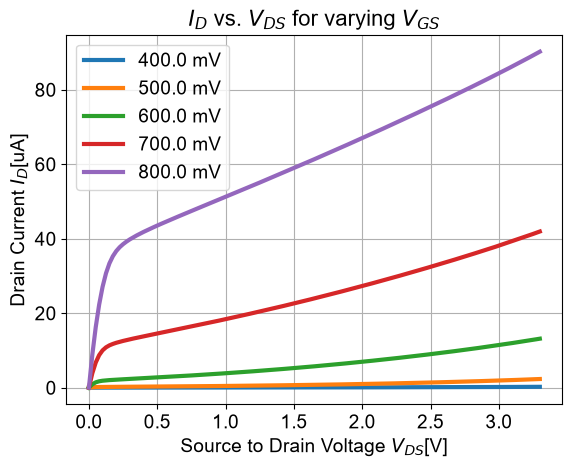

In [6]:
VDS = nch['VDS']
VGS = np.arange(0.4, 0.81, 0.1)
VSB = 0
L = min(nch['L'])
ID = nch.look_up('ID', vgs=VGS, vds=VDS, vsb=VSB, L=L)

plt.plot(VDS, np.transpose(ID)*1e6, linewidth = 3);
plt.title(r'$I_D$ vs. $V_{DS}$ for varying $V_{GS}$', weight='normal',fontsize=16)
plt.xlabel(r'Source to Drain Voltage $V_{DS}$[V]',weight='normal',fontsize=14);
plt.ylabel(r'Drain Current $I_D$[uA]', weight='normal',fontsize=14);
plt.xticks(weight='normal',fontsize=14);
plt.yticks(weight='normal',fontsize=14);
plt.grid()
# Custom Legends with VGS values using num2eng
plt.legend([f'{num2eng(vgs)}V' for vgs in VGS],prop = { "size": 14 ,'weight':'normal'}, loc ="upper left")
plt.show()

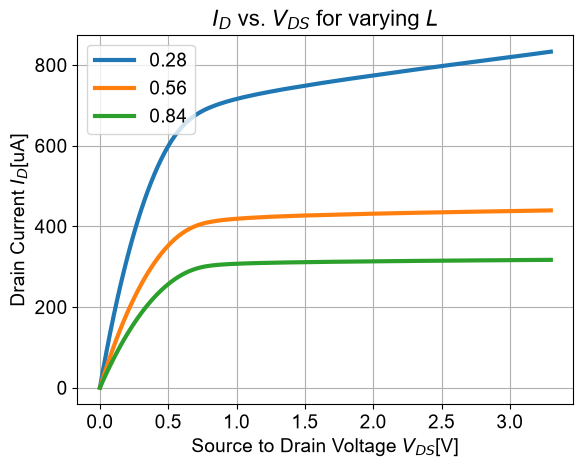

In [14]:
VDS = nch['VDS']
VGS = max(nch['VDS'])/2
VSB = 0
L = np.arange(min(nch['L']),3.1*min(nch['L']),min(nch['L']))
ID = nch.look_up('ID', vgs=VGS, vds=VDS, vsb=VSB, L=L)

plt.plot(VDS, np.transpose(ID)*1e6, linewidth = 3);
plt.title(r'$I_D$ vs. $V_{DS}$ for varying $L$', weight='normal',fontsize=16)
plt.xlabel(r'Source to Drain Voltage $V_{DS}$[V]',weight='normal',fontsize=14);
plt.ylabel(r'Drain Current $I_D$[uA]', weight='normal',fontsize=14);
plt.xticks(weight='normal',fontsize=14);
plt.yticks(weight='normal',fontsize=14);
plt.grid()
plt.legend(np.round(L, 2),prop = { "size": 14 ,'weight':'normal'}, loc ="upper left")
plt.show()

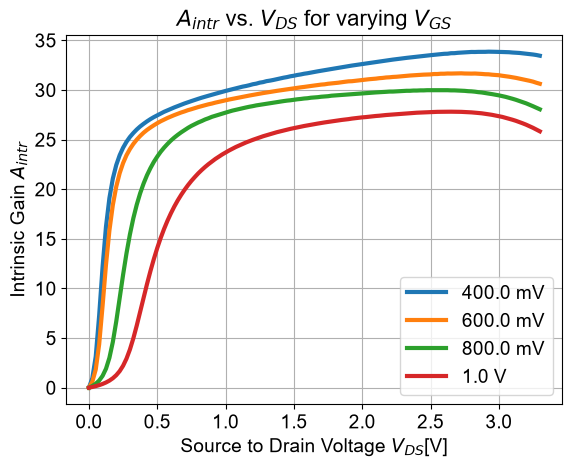

In [8]:
VDS = nch['VDS']
VGS = np.arange(0.4, 1.1, 0.2)
VSB = 0
L = min(nch['L'])
Aintr = nch.look_up('GM_GDS', vgs=VGS, vds=VDS, vsb=VSB, L=L)

plt.plot(VDS, np.transpose(Aintr), linewidth = 3);
plt.title(r'$A_{intr}$ vs. $V_{DS}$ for varying $V_{GS}$', weight='normal',fontsize=16)
plt.xlabel(r'Source to Drain Voltage $V_{DS}$[V]',weight='normal',fontsize=14);
plt.ylabel(r'Intrinsic Gain $A_{intr}$', weight='normal',fontsize=14);
plt.xticks(weight='normal',fontsize=14);
plt.yticks(weight='normal',fontsize=14);
plt.grid()
# Custom Legends with VGS values using num2eng
plt.legend([f'{num2eng(vgs)}V' for vgs in VGS],prop = { "size": 14 ,'weight':'normal'}, loc ="lower right")
plt.show()

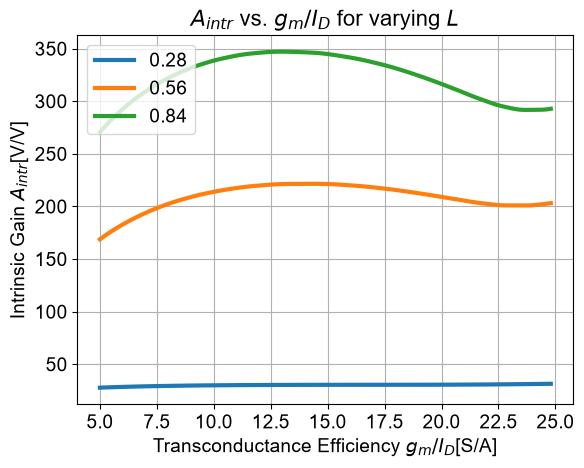

In [15]:
gmID = np.arange(5, 25, 0.2)
VDS = max(nch['VDS'])/2
VSB = 0
L = np.arange(min(nch['L']),3.1*min(nch['L']),min(nch['L']))
Aintr = nch.look_up('GM_GDS', GM_ID=gmID, vds=VDS, vsb=VSB, L=L)

plt.plot(gmID, np.transpose(Aintr), linewidth = 3);
plt.title(r'$A_{intr}$ vs. $g_{m}/I_D$ for varying $L$', weight='normal',fontsize=16)
plt.xlabel(r'Transconductance Efficiency $g_{m}/I_D$[S/A]',weight='normal',fontsize=14);
plt.ylabel(r'Intrinsic Gain $A_{intr}$[V/V]', weight='normal',fontsize=14);
plt.xticks(weight='normal',fontsize=14);
plt.yticks(weight='normal',fontsize=14);
plt.grid()
plt.legend(np.round(L, 2),prop = { "size": 14 ,'weight':'normal'}, loc ="upper left")
plt.show()